# PanTS Data Understanding: EDA Notebook
3D Pancreas-Aware Pancreatic Lesion Segmentation (Week 2, M2A1)

This notebook profiles the real PanTS dataset from the manifest built by `scripts/build_manifest.py`, and connects each finding to a concrete modeling decision. Every number here comes from the actual 9,901 cases on disk.

In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# locate the manifest by walking up from the notebook location
root = Path.cwd()
while not (root / 'outputs' / 'manifest.csv').exists() and root != root.parent:
    root = root.parent
df = pd.read_csv(root / 'outputs' / 'manifest.csv')
df['has_lesion'] = df['has_lesion'].astype(bool)
print(f'Loaded manifest: {len(df)} cases, {df.shape[1]} columns')

Loaded manifest: 9901 cases, 29 columns


## 1. Dataset overview
The public PanTS Mini release: one 3D abdominal CT volume per case, each paired with voxel-wise masks. Below are the true counts.

In [11]:
print('Split counts     :', df['split'].value_counts().to_dict())
print(f'Tumor-positive   : {df.has_lesion.sum()} ({100*df.has_lesion.mean():.1f}%)')
print(f'Tumor-free       : {(~df.has_lesion).sum()}')
for sp in ['train','test']:
    s = df[df.split==sp]
    print(f'  {sp:5s}: {len(s):5d} cases, {100*s.has_lesion.mean():.1f}% tumor')

Split counts     : {'train': 9000, 'test': 901}
Tumor-positive   : 1033 (10.4%)
Tumor-free       : 8868
  train:  9000 cases, 9.8% tumor
  test :   901 cases, 16.8% tumor


Interpretation: only about 10% of scans contain a tumor, and inside a tumor scan the lesion is a tiny fraction of the volume. This severe class imbalance is the single biggest driver of the training design: it is why we sample patches that are biased toward lesion voxels and use a Dice-based loss instead of plain cross-entropy. Note also that the official test split is deliberately tumor-richer (about 17% vs 10% in training), which matters when reading evaluation numbers.

## 2. Visualization 1: Tumor prevalence by split

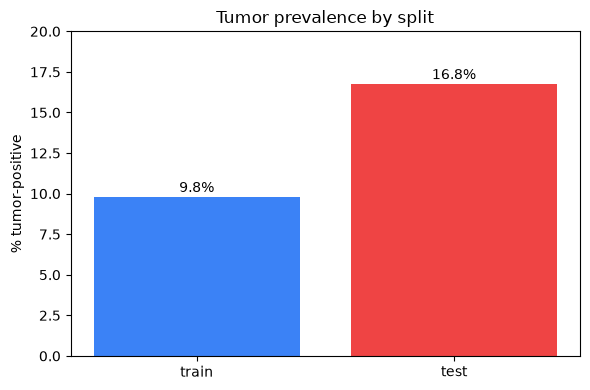

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
rates = df.groupby('split')['has_lesion'].mean().reindex(['train','test'])*100
ax.bar(['train','test'], rates.values, color=['#3b82f6','#ef4444'])
for i,v in enumerate(rates.values): ax.text(i, v+0.3, f'{v:.1f}%', ha='center')
ax.set_ylabel('% tumor-positive'); ax.set_ylim(0,20)
ax.set_title('Tumor prevalence by split'); plt.tight_layout(); plt.show()

This confirms the imbalance visually and shows the train/test prevalence gap. Because a tumor-free scan cannot contribute a meaningful lesion-Dice score, this chart is also why we evaluate lesion accuracy only on tumor-positive cases and measure specificity separately on tumor-free ones.

## 3. Visualization 2: Lesion volume distribution (tumor cases)

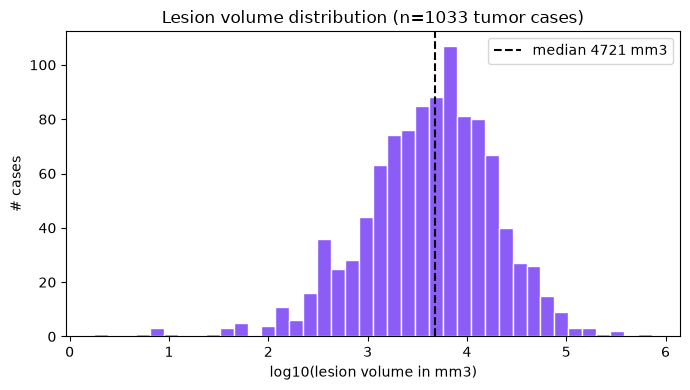

min 2 | 25% 1655 | median 4721 | 75% 11466 | max 732388 mm3
tiny lesions < 100 mm3: 17 cases


In [13]:
v = df.loc[df.has_lesion, 'lesion_volume_mm3'].clip(lower=1)
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.log10(v), bins=40, color='#8b5cf6', edgecolor='white')
ax.axvline(np.log10(v.median()), color='k', ls='--', label=f'median {v.median():.0f} mm3')
ax.set_xlabel('log10(lesion volume in mm3)'); ax.set_ylabel('# cases')
ax.set_title(f'Lesion volume distribution (n={len(v)} tumor cases)')
ax.legend(); plt.tight_layout(); plt.show()
print('min %.0f | 25%% %.0f | median %.0f | 75%% %.0f | max %.0f mm3' % (
    v.min(), v.quantile(.25), v.median(), v.quantile(.75), v.max()))
print('tiny lesions < 100 mm3:', int((v<100).sum()), 'cases')

Lesion size spans five orders of magnitude, from around 2 mm3 up to 730,000 mm3, with a median near 4,700 mm3. A handful of lesions are smaller than 100 mm3, essentially a few voxels. This directly informs two decisions: the model must handle very small targets (so patch sampling and loss weighting matter), and at inference we apply a small minimum-volume threshold so scattered single-voxel predictions are treated as noise rather than tumors.

## 4. Visualization 3: Scan geometry heterogeneity

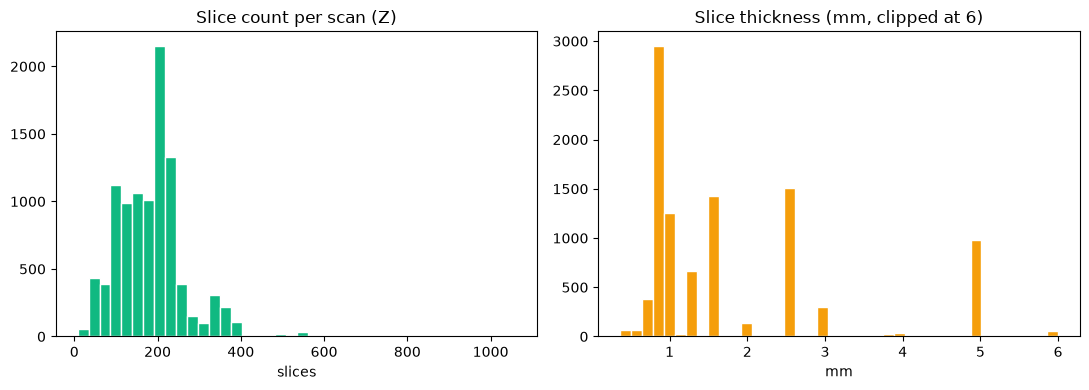

slices Z : min 8 median 190 max 1060
in-plane spacing: min 0.42 median 0.81 max 5.00 mm
slice spacing   : min 0.36 median 1.25 max 10.00 mm


In [14]:
sh = df['shape'].str.split('x', expand=True).astype(float)
spc = df['spacing'].str.split(',', expand=True).astype(float)
fig, axs = plt.subplots(1, 2, figsize=(11,4))
axs[0].hist(sh[2], bins=40, color='#10b981', edgecolor='white')
axs[0].set_title('Slice count per scan (Z)'); axs[0].set_xlabel('slices')
axs[1].hist(spc[2].clip(upper=6), bins=40, color='#f59e0b', edgecolor='white')
axs[1].set_title('Slice thickness (mm, clipped at 6)'); axs[1].set_xlabel('mm')
plt.tight_layout(); plt.show()
print('slices Z : min %.0f median %.0f max %.0f' % (sh[2].min(), sh[2].median(), sh[2].max()))
print('in-plane spacing: min %.2f median %.2f max %.2f mm' % (spc[0].min(), spc[0].median(), spc[0].max()))
print('slice spacing   : min %.2f median %.2f max %.2f mm' % (spc[2].min(), spc[2].median(), spc[2].max()))

The scans are wildly inconsistent in geometry: slice counts run from 8 to over 1,000, and voxel spacing ranges from sub-millimeter to 5 mm in-plane and up to 10 mm between slices. A model cannot learn from raw voxels at these inconsistent scales, so this is the justification for the core preprocessing step: reorient every scan to a standard orientation and resample it to a common 1.5 mm isotropic grid before training. It is also why some scans end up thinner than the patch size and need padding.

## 5. Visualization 4: Acquisition: contrast phase and sites

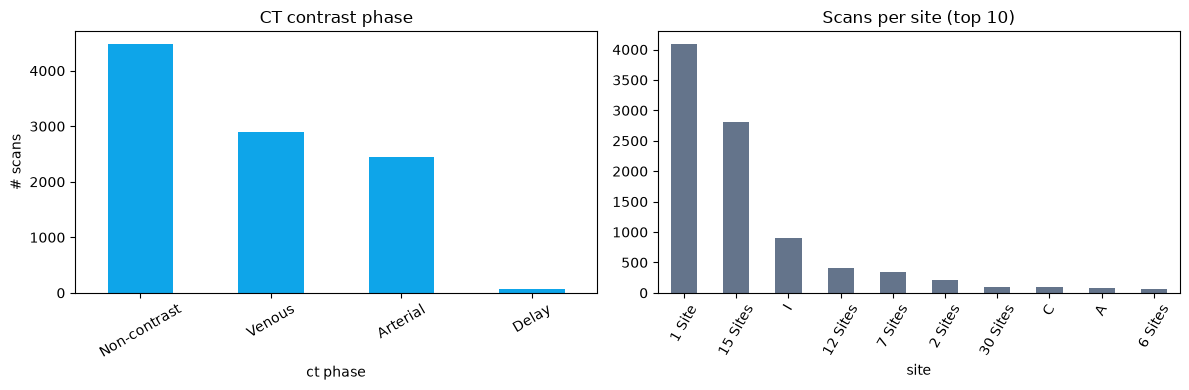

manufacturers: 4 real makers ['GE', 'Philips', 'Siemens', 'Toshiba'] from 6 raw strings (GE and Philips each appear under two spellings)
nationalities: 14
site field: mixes grouped labels ("15 Sites", "12 Sites") with individual codes, so it encodes many more than 20 institutions, not 20 distinct sites


In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
df['ct phase'].value_counts().plot.bar(ax=axs[0], color='#0ea5e9')
axs[0].set_title('CT contrast phase'); axs[0].set_ylabel('# scans'); axs[0].tick_params(axis='x', rotation=30)
df['site'].value_counts().head(10).plot.bar(ax=axs[1], color='#64748b')
axs[1].set_title('Scans per site (top 10)'); axs[1].tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.show()

# Honest counts: collapse double-counted vendor spellings and flag the grouped site labels.
maker_map = {'SIEMENS':'Siemens', 'GE MEDICAL SYSTEMS':'GE', 'GE':'GE',
             'Philips':'Philips', 'Philips Medical Systems':'Philips', 'TOSHIBA':'Toshiba'}
raw_makers = df['manufacturer'].nunique()
real_makers = sorted(df['manufacturer'].dropna().map(maker_map).unique())
print(f'manufacturers: {len(real_makers)} real makers {real_makers} from {raw_makers} raw strings '
      f'(GE and Philips each appear under two spellings)')
print(f'nationalities: {df["site nationality"].nunique()}')
print('site field: mixes grouped labels ("15 Sites", "12 Sites") with individual codes, '
      'so it encodes many more than 20 institutions, not 20 distinct sites')

The data spans multiple contrast phases (non-contrast, venous, arterial, delay), many institutions across 14 nationalities, and four scanner manufacturers (Siemens, GE, Philips, Toshiba). Two metadata quirks I corrected for honesty: the manufacturer field has six raw strings but only four real makers, because GE and Philips are each recorded under two spellings; and the site field mixes grouped labels like '15 Sites' with individual letter codes, so it represents many more than twenty institutions rather than twenty distinct sites. This diversity is a strength for generalization, but it is also a source of the intensity and geometry variability above, which is why intensity windowing and resampling are non-negotiable. It also frames the honest limitation that a model trained on a 100-case subset sees only a slice of this diversity.

## 6. Visualization 5: Label validation against the dataset's own tumor flag

In [16]:
t = df['tumor?'].astype(str).str.strip()
meta_pos = t.isin(['1','yes','Yes','true','True'])
ct = pd.crosstab(df.has_lesion, meta_pos, rownames=['mask-derived has_lesion'], colnames=['metadata tumor?'])
print(ct)
print(f'Agreement: {100*(meta_pos==df.has_lesion).mean():.1f}%')

metadata tumor?          False  True 
mask-derived has_lesion              
False                     8824     44
True                         0   1033
Agreement: 99.6%


As an independent check, our tumor label (derived by counting voxels in the lesion mask) agrees with the dataset's own tumor flag 99.6% of the time. That is strong evidence the label pipeline is wired correctly. The small number of disagreements are cases where the metadata flags a tumor but the lesion mask is empty, which is worth flagging as a data anomaly rather than trusting blindly.

## 7. Data quality summary

In [17]:
print('Mask completeness  : missing pancreas', int((df.pancreas_path.fillna("")=="").sum()),
      '| missing lesion', int((df.lesion_path.fillna("")=="").sum()))
print('Duplicate case_ids :', int(df.case_id.duplicated().sum()))
print('Structures per case:', df['n_structures'].min(), 'to', df['n_structures'].max())
print('Missing age        :', int(df['age'].isna().sum()), f'({100*df["age"].isna().mean():.0f}%)')
print('Sex values         :', df['sex'].value_counts(dropna=False).to_dict())

Mask completeness  : missing pancreas 0 | missing lesion 0
Duplicate case_ids : 0
Structures per case: 27 to 28
Missing age        : 4809 (49%)
Sex values         : {nan: 4619, 'M': 2923, 'F': 2358, 'M ': 1}


Key points. The image and mask data are complete: every case has a pancreas and a lesion mask file, there are no duplicate cases, and each case carries around 28 structure masks. The demographic metadata, on the other hand, is messy: roughly half of the age and sex fields are missing, and there is a stray sex value of 'M ' with a trailing space. This does not affect the project, because this is a vision task whose model inputs are the CT voxels, not the tabular metadata. The only cleaning that matters for us is standardizing the images, and stripping whitespace if we ever report demographics.

## 8. What this means for the model

**The three most important findings (the spine of the talk):** (1) class imbalance, only about 10% of scans have a tumor and each lesion is a tiny fraction of a volume; (2) geometry heterogeneity, slice counts and voxel spacing vary more than tenfold across scans; (3) over-prediction, the first honest evaluation showed the model finds tumors but flags them almost everywhere (8% specificity), which I diagnosed and then largely fixed with the whole-box change. The first two are EDA findings from the manifest; the third came out of the first real evaluation and is the one that reshaped the plan. Each finding below maps to a concrete modeling decision.

- Severe imbalance (10% tumor scans, tiny lesions) -> positive-biased patch sampling plus a Dice-based loss, and lesion accuracy reported only on tumor cases.
- Huge geometry variability -> resample to 1.5 mm isotropic and window CT intensities before training.
- Over-prediction found at first evaluation -> diagnosed as a field-of-view problem and largely fixed by feeding the whole pancreas box as one cube (specificity 8% -> 55%); a minimum-volume threshold and largest-component cleanup remain as inference-time fallbacks.
- Multi-site diversity -> good for generalization, but a 100-case development subset is a real limitation to state honestly.
- Labels validated at 99.6% against the dataset's own flag -> confidence that the segmentation targets are correct.
- The input 'feature' is the preprocessed 3D CT volume itself; the surrounding anatomy masks are candidate auxiliary inputs for a later anatomy-context experiment.


## 9. The overfit-a-single-batch test (Stage 0 sanity gate)
Before trusting any real training run, the pipeline has to prove it can memorize a tiny fixed set of cases. If the network cannot drive training loss down on a handful of samples, something is broken (data, loss, or gradients). Below is the actual Stage 0 result logged to MLflow.

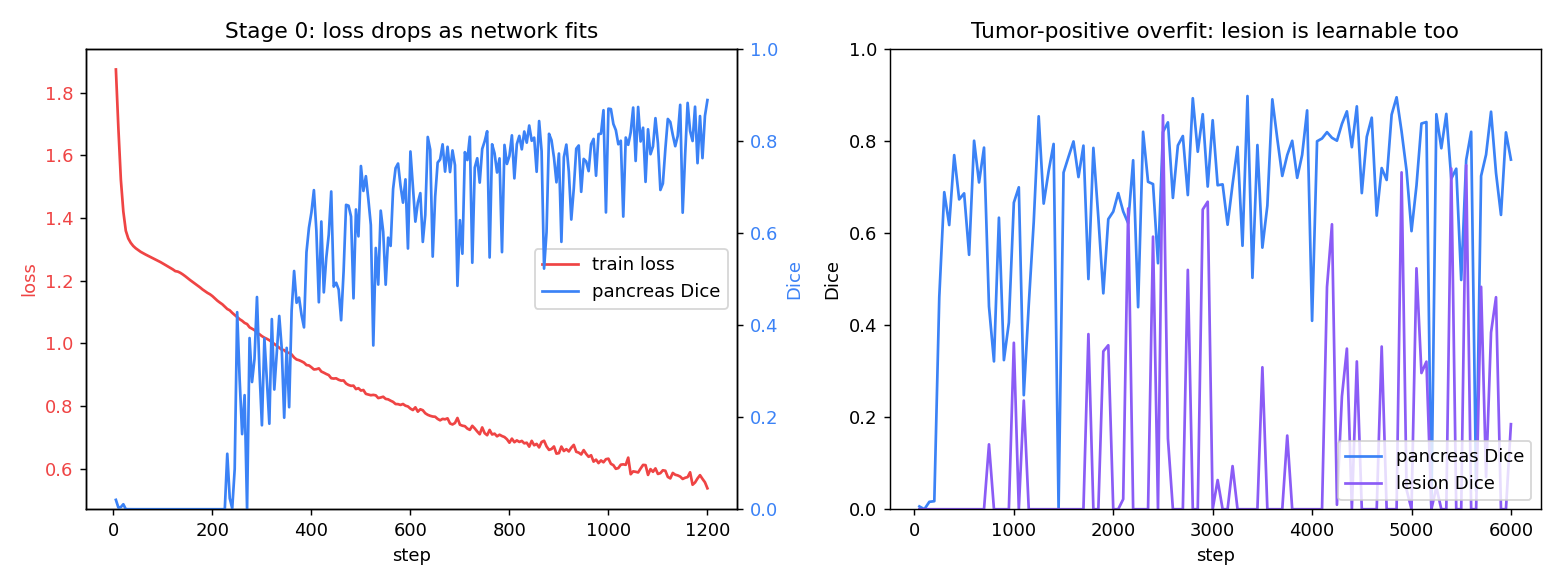

In [18]:
from IPython.display import Image
Image('overfit_curve.png')

Left: on a fixed batch the training loss falls smoothly from 1.87 to 0.54 while pancreas Dice climbs to 0.89. That is the gate passing, the pipeline learns. Right: on a tumor-positive overfit the lesion Dice rises from 0 to about 0.85, confirming the network can fit the hard minority class too, not just the easy pancreas. The lesion curve is spiky because Dice is measured on rotating random crops, not because learning is unstable. This is the evidence that the architecture, loss, and data path are wired correctly before spending compute on full runs.